# fBm / MRW gaussian_experiment — interactive run

Interactive, cell-by-cell counterpart to `gaussian_experiment/run_SDE.py`, for
checking that an experiment is set up correctly *before* launching a full
sweep on the cluster (`launch_SDE.sh`). Same steps, same functions, same
config/output layout — but every figure renders inline instead of only being
written to `figures/`, and every parameter is a variable you can tweak and
re-run a cell for.

**Defaults here are reduced for speed** (`n1=100`, `nt=100` vs the
production launch script's `n1=5000`, `nt=60000`) — the SDE step is the
expensive part and this machine is CPU-only (real production runs happen on
Jean Zay, see `CLAUDE.md`). Bump `n1`/`nt`/`M` back up once you're confident
the setup (Hurst, intermittency, terms, ...) is right and want a more
statistically meaningful check, or just launch the real sweep.


In [ ]:
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import math
import sys
from pathlib import Path
from types import SimpleNamespace

# Notebook lives in gaussian_experiment/; 'codes' and 'data' live in the
# parent folder — same sys.path setup as gaussian_experiment/run_SDE.py.
root = Path.cwd()
project_root = root.parent

for p in (root, project_root, project_root / 'codes', project_root / 'data'):
    if p.is_dir() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

from codes.sde_routines import *
from codes.utils import *
from codes.utils_experiment import *
from codes.check_moments import *
from codes.check_potentials import _decode_scattering_jsk
from codes.ortho_wavelet.ReadyToUseWavelets import *
from data.synthetic_data_generator import *
from IPython.display import Image, display

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


`codes/potentials/potentials_1d.py` force-sets the matplotlib backend to
`Agg` (headless) as a side effect of the import above — necessary for the
non-interactive `run_SDE.py`, but it also kills inline figures here. Re-run
`%matplotlib inline` now that the imports are done, and again before each
plot below (same workaround `turbulence/run_analyse_MGD_experiment.ipynb`
uses).


In [ ]:
%matplotlib inline

## Parameters

Mirrors the CLI args of `run_SDE.py` — see that file's `parse_args()` for the full/production defaults.

In [ ]:
args = SimpleNamespace(
    timestamp=None,

    # Data
    n1=1000,             # dataset size (production default: 3000+)
    M=128,              # signal length (= number of increments per path)
    hurst=0.5,          # Hurst exponent (0.5 = standard Brownian motion)
    intermittency=0.0,  # MRW intermittency (lam); 0.0 = pure fBm increments

    # Wavelet scattering
    J=7,
    Q=1,
    terms=[
        #'Scattering_First_Order', 
        'Scattering_Second_Order', 
        #'Scattering_Fourth_Order_Mod2_Real_Q1',
        #'Scattering_Fourth_Order_Mod2_Imag_Q1',
    ],

    # SDE
    nt=500,              # integration steps (production default: 8000+)
    sigma=1.,
    schedule_exponent=2,
    interpolant='Cos',
    regularization=1e-2,
    lam=5e-6,            # SDE regularization strength -- not the MRW intermittency
    n_subsample=1,

    # Batch
    batch_size=None,

    # Diagnostics
    n_traj_groups=2,
    n_tau=30,
    moment_threshold=1e-8,
    n_acf_lags=40,

    # Experiment / bookkeeping
    outdir=None,
    label='hurst.75_normalized_all_potentials', # new label for testing out the normalization 
    force_rerun=False,
    no_save_aux_moments=False,
    seed=0,
)

normalize_potentials = True

torch.manual_seed(args.seed)
np.random.seed(args.seed)


## Data generation

`load_synthetic_data('mrw', ...)` with `intermittency=0` reduces the MRW
model to a pure fBm — its increments are then plain fractional Gaussian
noise. Increments, not the raw process, because fBm itself isn't stationary
(variance grows as `t^(2H)`), while its increments are.


In [ ]:
outdir = Path(args.outdir) if args.outdir else root
outdir.mkdir(parents=True, exist_ok=True)

raw = load_synthetic_data(
    'mrw', args.n1, args.M + 1,
    lam=args.intermittency, H=args.hurst,
).to(device)
increments = raw.diff(dim=-1)  # (n1, 1, M)

x1 = normalize(increments).to(device)
B, channels, M = x1.shape
print('raw shape:', tuple(raw.shape))
print('x1 (increments, normalized) shape:', tuple(x1.shape))


In [ ]:
print("Raw time series, Brownian motion") 
plot_time_series_row(raw, 10)
print("Increments") 
plot_time_series_row(x1, 10)

## Resolve experiment output

Same `resolve_or_setup_experiment_output` as `run_SDE.py`, at the same point
in the pipeline (right after `x1` is built) — this is what makes everything
below land in the *exact* same `gaussian_experiment/experiments/<config>/`
and `saved_results/` folders, under the same filenames, as running
`run_SDE.py` with these arguments would. It also reuses a saved run if one
with matching parameters already exists (set `args.force_rerun = True` above
to ignore that and rerun from scratch).


In [ ]:
config, exp_dir, fig_dir, potentials_dir, logger, loaded = resolve_or_setup_experiment_output(
    outdir, args, M, device, coarse_grained=False,
    extra_metadata={'M': M, 'B': B, 'channels': channels},
    include_potentials_dir=True,
)
print('config:', config)
print('exp_dir:', exp_dir)


config: gaussiansynth_H0.5_intermittency0.0_M128_J7_Q3_sigma0.3_nt100_n1_100_lam5e-06_seed_0_terms9559d19a_notebook_check
exp_dir: /home/chiaraz/phd/MGD-for-Maximum-Entropy-Generation/gaussian_experiment/experiments/gaussiansynth_H0.5_intermittency0.0_M128_J7_Q3_sigma0.3_nt100_n1_100_lam5e-06_seed_0_terms9559d19a_notebook_check


## Increment sanity check

Identical to `plot_increment_diagnostics()` in `run_SDE.py` — writes
`figures/increment_diagnostics.png` into `fig_dir` exactly as the script
does, then redisplays that same file inline (plotting functions here either
save-to-disk or show inline, never both, so redisplaying the saved file is
how this notebook gets both without diverging from the script's code path).


In [ ]:
%matplotlib inline
def plot_increment_diagnostics(x1, args, fig_dir, config, n_show=5):
    x = x1[:, 0, :].detach().cpu().numpy()
    B, M = x.shape
    max_lag = min(args.n_acf_lags, M - 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    for i in range(min(n_show, B)):
        axes[0].plot(x[i], lw=1, alpha=0.8)
    axes[0].set_title('Example increment traces')
    axes[0].set_xlabel('index'); axes[0].set_ylabel('increment')

    axes[1].hist(x.ravel(), bins=100, density=True, log=True)
    axes[1].set_title('Increment marginal (log density)')
    axes[1].set_xlabel('increment value'); axes[1].set_ylabel('density')

    x_centered = x - x.mean()
    var = x_centered.var()
    acf_emp = np.array([
        1.0 if lag == 0 else
        np.mean(x_centered[:, :M - lag] * x_centered[:, lag:]) / var
        for lag in range(max_lag + 1)
    ])
    k = np.arange(0, max_lag + 1)
    acf_theory = 0.5 * (
        np.abs(k + 1) ** (2 * args.hurst)
        - 2 * np.abs(k) ** (2 * args.hurst)
        + np.abs(k - 1) ** (2 * args.hurst)
    )
    acf_theory[0] = 1.0

    axes[2].plot(k, acf_emp, 'o-', ms=4, label='empirical')
    axes[2].plot(k, acf_theory, 'k--', label=f'theoretical fGn (H={args.hurst})')
    axes[2].axhline(0, color='grey', lw=0.5)
    axes[2].set_xlabel('lag'); axes[2].set_ylabel('autocorrelation')
    axes[2].legend()
    axes[2].set_title('Increment autocorrelation')

    fig.suptitle(f'H={args.hurst}, intermittency={args.intermittency}', fontsize=12)
    fig.tight_layout()
    fig.savefig(fig_dir / 'increment_diagnostics.png', dpi=150, bbox_inches='tight')
    plt.close(fig)

plot_increment_diagnostics(x1, args, fig_dir, config)
display(Image(filename=str(fig_dir / 'increment_diagnostics.png')))


If the setup is correct: the middle panel is a symmetric Gaussian-looking
histogram when `intermittency=0` (fat-tailed once `intermittency>0`), and
the right panel's empirical curve should track the theoretical fGn curve
closely — a mismatch there means `hurst`/`intermittency` aren't doing what
you expect.


## Filters & potentials

In [8]:
filters, filters_Phi = return_Filters(M, args.J, 1, device=device, include_phi=True)
filters_Q = return_Filters(M, args.J, args.Q, device=device)

t = 1 - (1 - torch.linspace(0, 1, args.nt + 1)) ** args.schedule_exponent
t_rounded = torch.round(t, decimals=4)
t_final = int((t_rounded == 1.0).nonzero(as_tuple=True)[0][0])
print(f"t_final = {t_final}/{len(t)} (last t = {t[t_final-1].item():.6f}, "
      f"dropping {len(t) - t_final} redundant trailing points at 1.0000)")


t_final = 497/501 (last t = 0.999936, dropping 4 redundant trailing points at 1.0000)


Potentials with a fit_micro normalization: ['Scattering_Second_Order']


/tmp/xpython_3597013/4081950177.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_norm.legend()


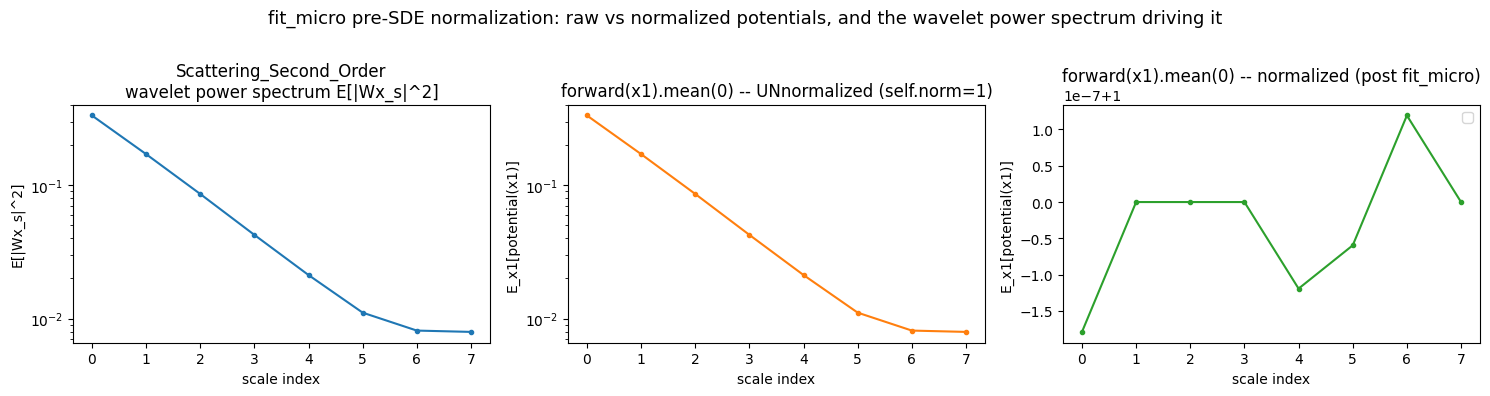

In [9]:
%matplotlib inline

# A separate, throwaway potentials dict -- built the exact same way
# run_experiment() builds its own (codes/utils_experiment.py:257) -- so
# calling fit_micro() on these has zero effect on the actual SDE run below.
diag_potentials = get_1d_potentials(
    args.terms, args.J, filters, args.Q, filters_Q=filters_Q, filters_Phi=filters_Phi,
    scalar_param=None, parallel=False,
)

# Only potentials fit_micro's normalization actually applies to: every class
# that sets self.norm=1 in __init__ (Scattering_{First,Second,Fourth_Order_*}_1d).
# Everything else (L_2, Scalar_*, ...) has no fit_micro-driven normalization.
normed_potentials = {k: p for k, p in diag_potentials.items() if hasattr(p, 'norm')}
print('Potentials with a fit_micro normalization:', list(normed_potentials.keys()))

scale_only = {k: p for k, p in normed_potentials.items() if not hasattr(p, 'indices')}
paired = {k: p for k, p in normed_potentials.items() if hasattr(p, 'indices')}


def _group_mean(x_vals, y_vals):
    # groupby-mean without pandas (not imported in this notebook)
    uniq, inv = np.unique(x_vals, return_inverse=True)
    sums = np.bincount(inv, weights=y_vals, minlength=len(uniq))
    counts = np.bincount(inv, minlength=len(uniq))
    return uniq, sums / counts


rows = []  # (name, kind, spec_x, spec_y, raw_x, raw_y, norm_x, norm_y)

with torch.no_grad():
    for name, pot in scale_only.items():
        # RAW: forward() with self.norm==1 (fit_micro not called yet)
        forward_raw = pot(x1).mean(0).detach().cpu().numpy()

        # The normalization itself: E_x1[|Wx_s|^2] per scale, on pot's OWN
        # filter bank -- exactly what fit_micro computes before the **0.5,
        # i.e. this literally IS the wavelet power spectrum "driving" self.norm.
        Wx = torch.fft.ifft(pot.filters.to(x1.device) * torch.fft.fft(x1))
        spectrum = (Wx.abs() ** 2).mean(dim=(0, 2)).detach().cpu().numpy()

        pot.fit_micro(x1)  # sets self.norm = sqrt(spectrum), mutates pot in place
        forward_norm = pot(x1).mean(0).detach().cpu().numpy()

        scale_idx = np.arange(len(forward_raw))
        rows.append((name, 'scale', scale_idx, spectrum, scale_idx, forward_raw, scale_idx, forward_norm))

    for name, pot in paired.items():
        forward_raw = pot(x1).mean(0).detach().cpu().numpy()

        # fit_micro normalizes on the FINE bank (filters_Q), not the coarse
        # one -- see Scattering_Fourth_Order_Real_1d.fit_micro's docstring.
        Wx = torch.fft.ifft(pot.filters_Q.to(x1.device) * torch.fft.fft(x1))
        spectrum = (Wx.abs() ** 2).mean(dim=(0, 2)).detach().cpu().numpy()

        pot.fit_micro(x1)
        forward_norm = pot(x1).mean(0).detach().cpu().numpy()

        _, s1_arr, s2_arr = _decode_scattering_jsk(pot)
        scale_gap = np.abs(s1_arr - s2_arr)

        fine_idx = np.arange(len(spectrum))
        rows.append((name, 'paired', fine_idx, spectrum, scale_gap, np.abs(forward_raw), scale_gap, np.abs(forward_norm)))

fig, axes = plt.subplots(len(rows), 3, figsize=(15, 4 * len(rows)), squeeze=False)

for row_i, (name, kind, spec_x, spec_y, raw_x, raw_y, norm_x, norm_y) in enumerate(rows):
    ax_spec, ax_raw, ax_norm = axes[row_i]

    ax_spec.plot(spec_x, spec_y, 'o-', ms=3)
    ax_spec.set_yscale('log')
    ax_spec.set_title(f'{name}\nwavelet power spectrum E[|Wx_s|^2]')
    ax_spec.set_xlabel('fine scale index' if kind == 'paired' else 'scale index')
    ax_spec.set_ylabel('E[|Wx_s|^2]')

    if kind == 'scale':
        ax_raw.plot(raw_x, raw_y, 'o-', ms=3, color='C1')
        ax_norm.plot(norm_x, norm_y, 'o-', ms=3, color='C2')
        xlabel = 'scale index'
    else:
        gx, gy = _group_mean(raw_x, raw_y)
        ax_raw.plot(gx, gy, 'o-', ms=3, color='C1')
        gx, gy = _group_mean(norm_x, norm_y)
        ax_norm.plot(gx, gy, 'o-', ms=3, color='C2')
        xlabel = '|s1 - s2| (fine-scale separation)'

    ax_raw.set_xlabel(xlabel)
    ax_raw.set_title('forward(x1).mean(0) -- UNnormalized (self.norm=1)')
    ax_raw.set_ylabel('E_x1[potential(x1)]')
    ax_raw.set_yscale('log')

    #ax_norm.axhline(1.0, color='grey', ls='--', lw=1, label='y=1')
    ax_norm.legend()
    ax_norm.set_xlabel(xlabel)
    ax_norm.set_title('forward(x1).mean(0) -- normalized (post fit_micro)')
    ax_norm.set_ylabel('E_x1[potential(x1)]')

fig.suptitle('fit_micro pre-SDE normalization: raw vs normalized potentials, '
             'and the wavelet power spectrum driving it', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Run or load the SDE

In [10]:
fig_dir.mkdir(parents=True, exist_ok=True)

In [11]:

if loaded is not None:
    print('Loaded existing results (no SDE run).')
    result = loaded
else:
    result = run_experiment(args, M, config, x1, filters,
                            t[:t_final], logger, outdir, device,
                            filters_Q=filters_Q, filters_Phi=filters_Phi,
                            normalize_potentials=normalize_potentials,
                            potentials_save_dir=potentials_dir,
                            )


Loaded existing results (no SDE run).


In [19]:
theta_t = result["theta_t"]
theta_reg_t = result["Theta_reg"] 

In [20]:
theta_t.shape 

torch.Size([495, 8])

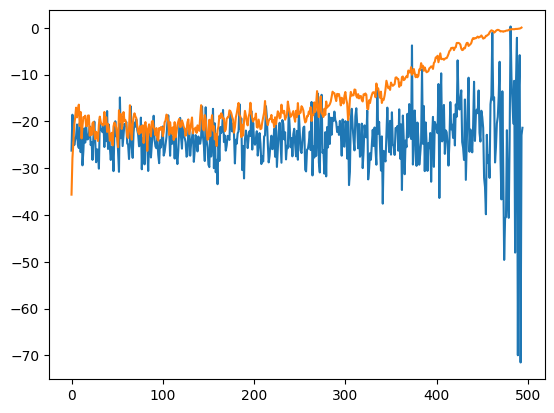

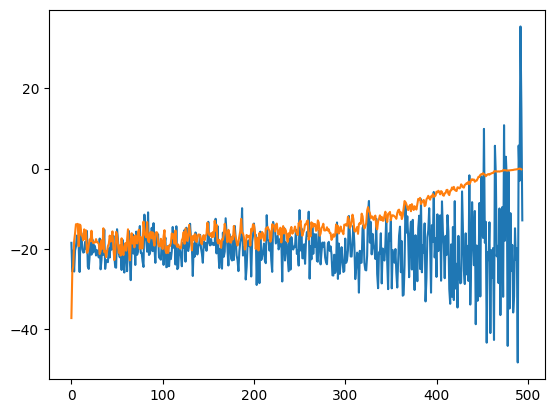

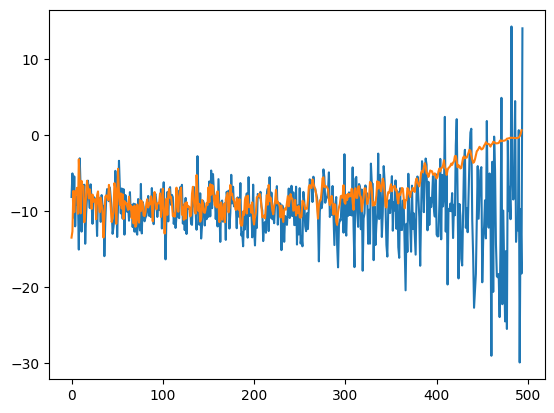

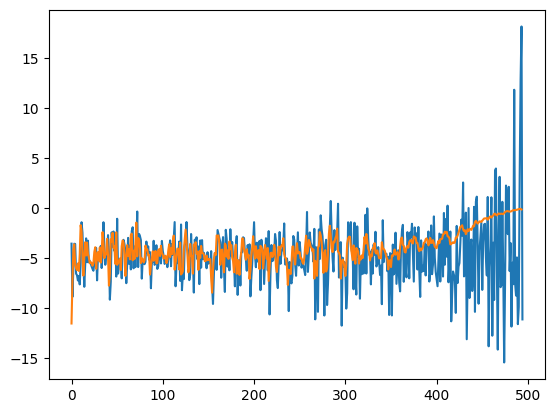

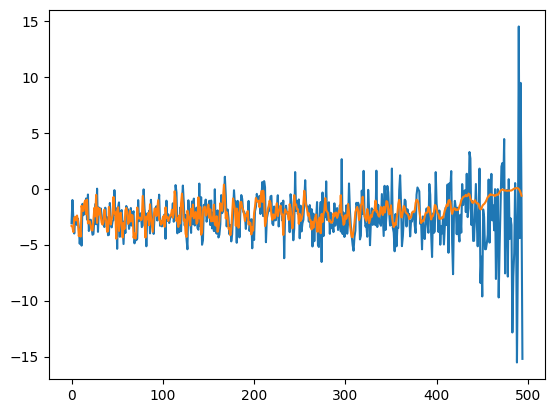

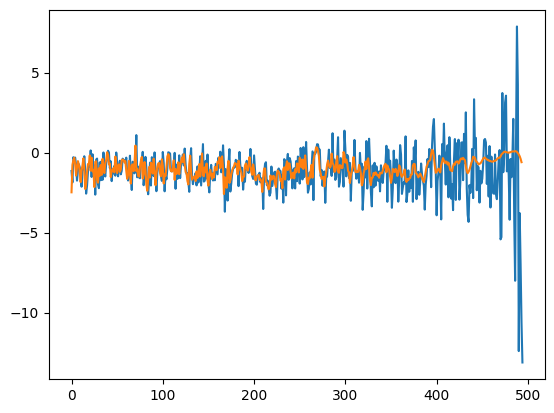

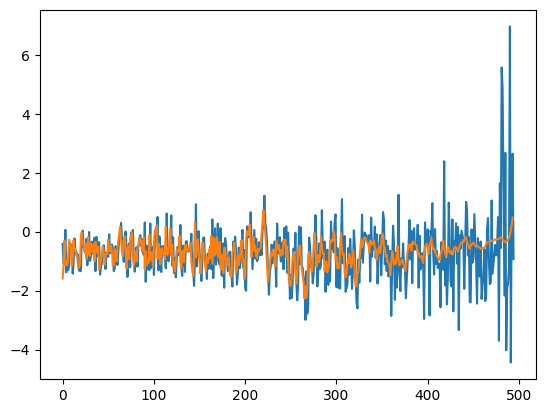

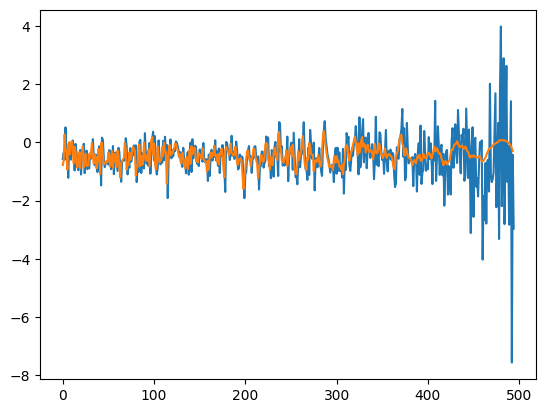

In [23]:
for i in range(0, theta_t.shape[-1]): 
    plt.plot(theta_t[:,i]) 
    plt.plot(theta_reg_t[:,i]) 
    plt.show() 

## Diagnostics

Same calls, same `save={"filename": ..., "title": ...}` dicts, same
filenames under `fig_dir`, as `save_diagnostics()` in `run_SDE.py` — each
one written to disk first, then redisplayed inline via the saved file
(matches the docstring note above: these functions save-or-show, never
both).

Note: `spec_plot`'s `save=` argument is a no-op upstream (in
`codes/check_moments.py` — it never reads `save["filename"]`), so, exactly
like `run_SDE.py`, no `spectrum.png` is written here either. It still
displays inline below via its own internal `plt.show()`, just isn't
persisted — this is a pre-existing bug in shared code, not something this
notebook does differently from the script.


### Wavelet coefficient histograms

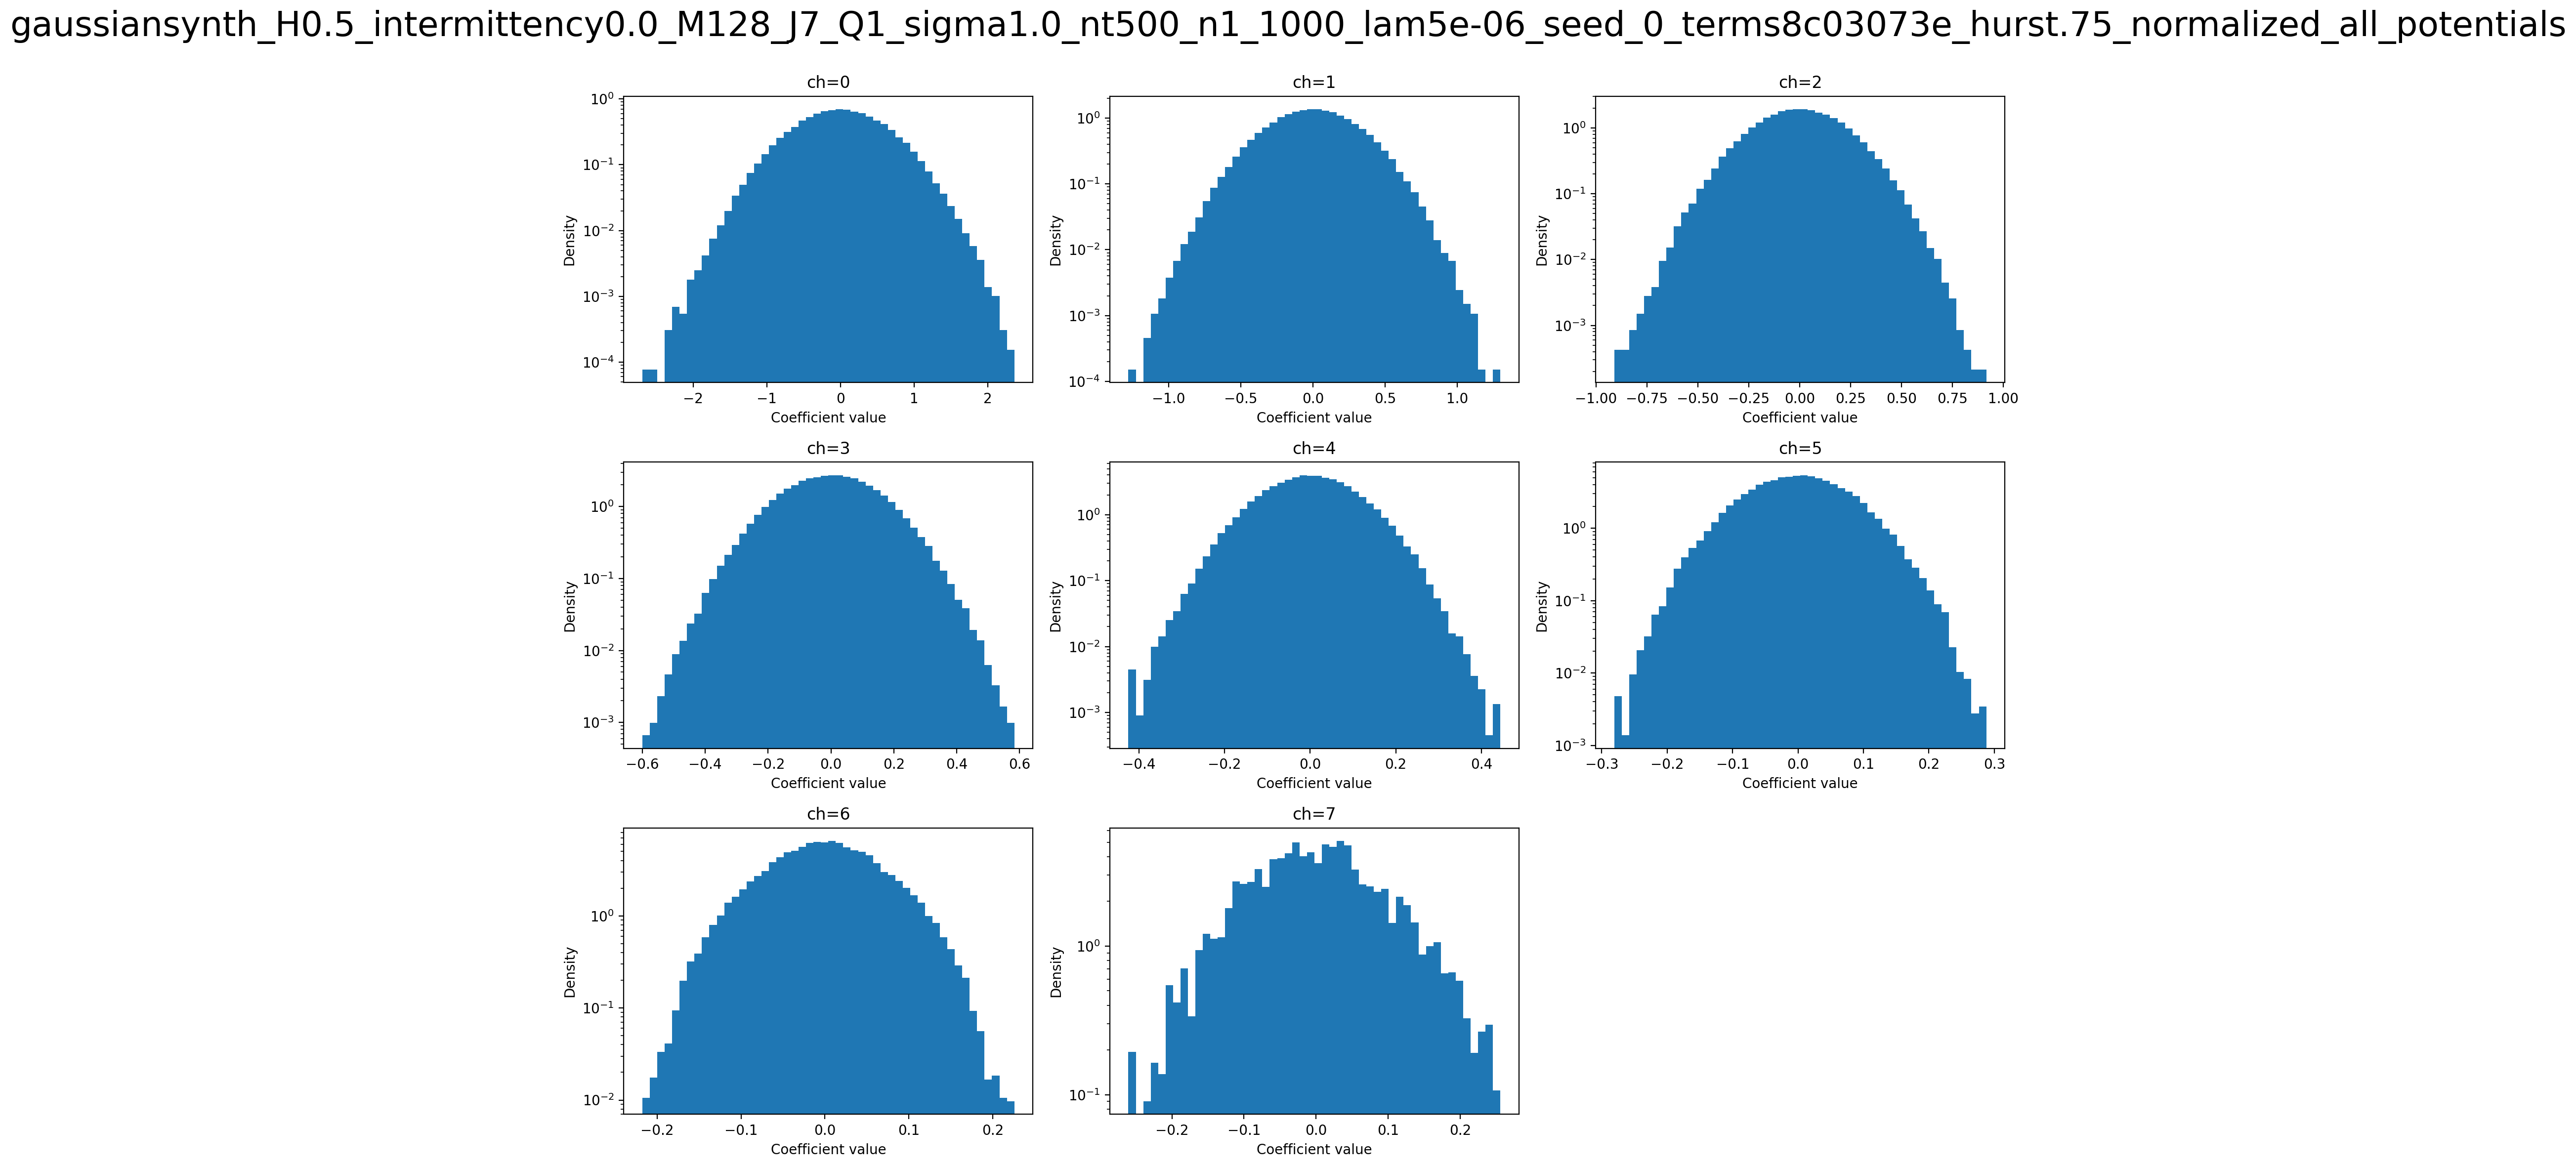

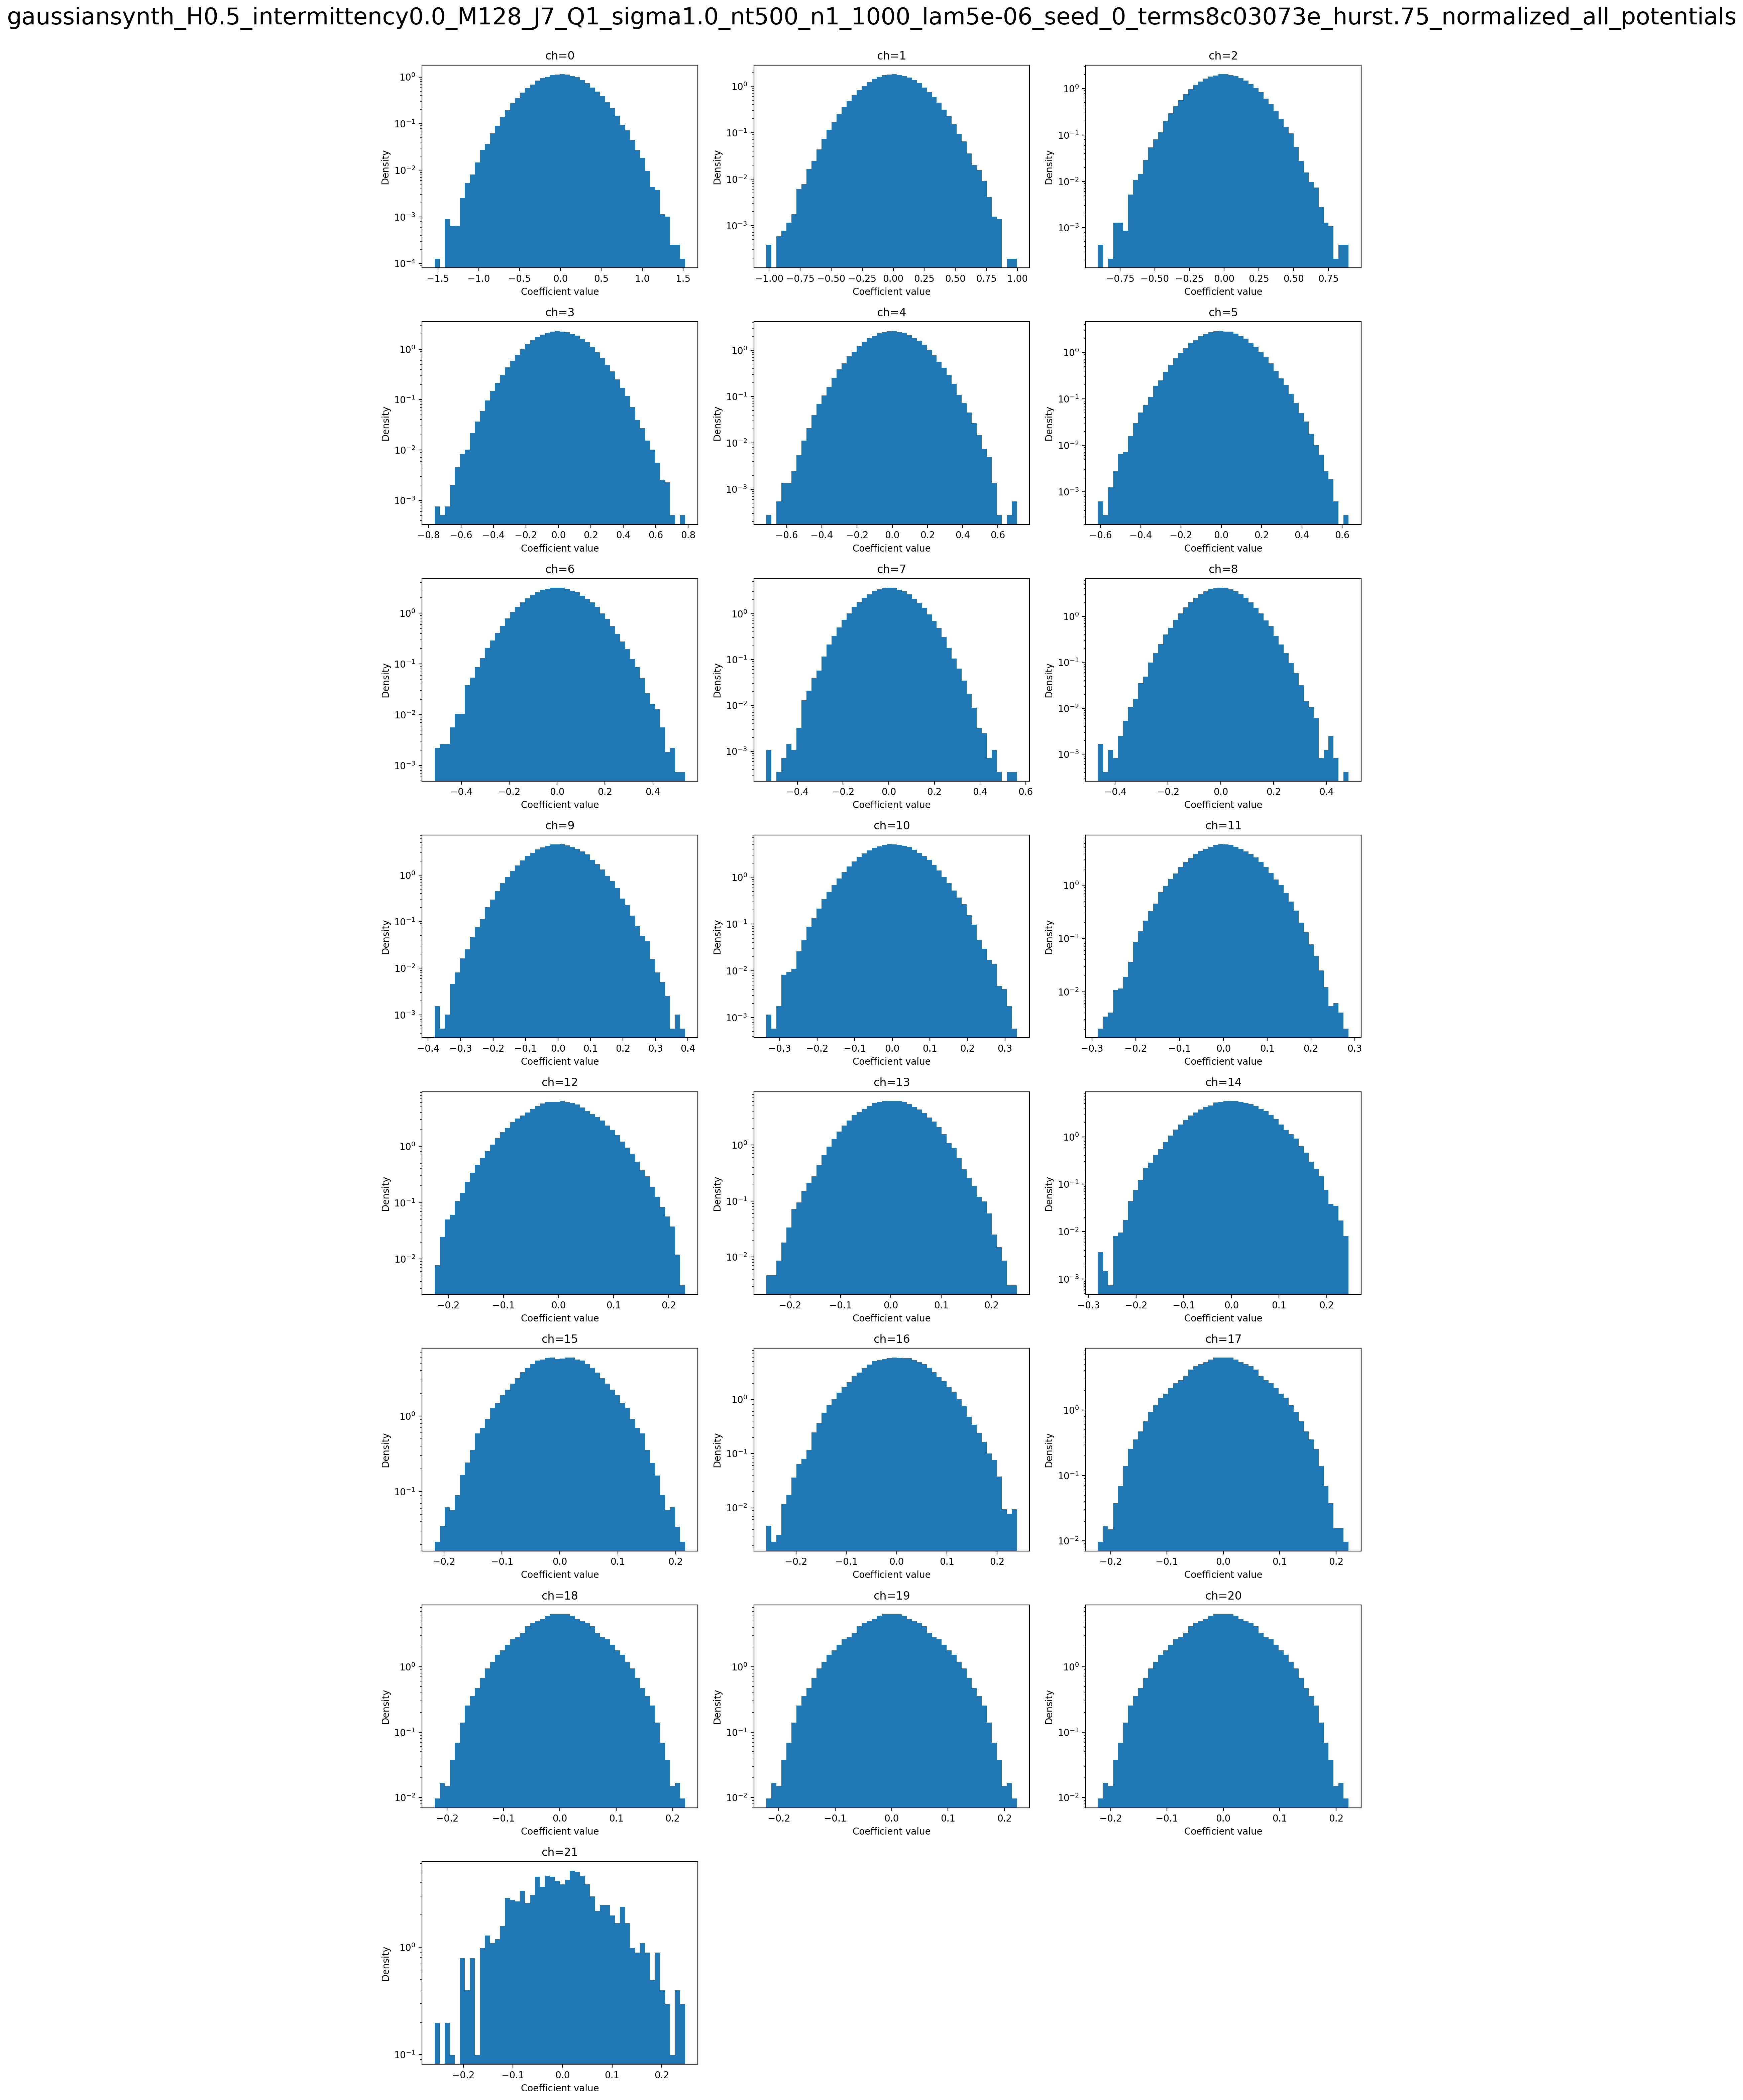

In [12]:
%matplotlib inline
def plot_wavelet_coeff_histograms(x1, J, Q, config, figdir, logger, save=None):
    B, channels, M = x1.shape
    filters = return_Filters(M, J, Q, device=device)
    wt = torch.fft.ifft(torch.fft.fft(x1) * filters).real  # (B, J, T)
    n_wavelets = filters.shape[1]

    ncols = 3
    nrows = math.ceil(n_wavelets / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    for i in range(n_wavelets):
        vals = wt[:, i, :].detach().cpu().flatten().numpy()
        axes[i].hist(vals, bins=50, density=True, log=True)
        axes[i].set_title(f"ch={i}")
        axes[i].set_xlabel("Coefficient value")
        axes[i].set_ylabel("Density")

    for j in range(n_wavelets, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Wavelet coefficient histograms (Q={Q})", fontsize=25)

    if save is not None:
        fig.suptitle(save["title"], fontsize=25)
        fig.tight_layout(rect=[0, 0, 1, 0.98])
        fig.savefig(save["filename"], dpi=200, bbox_inches="tight")
        plt.close(fig)
    else:
        fig.tight_layout()
        plt.show()

plot_wavelet_coeff_histograms(
    x1, args.J, 1, config, fig_dir, logger,
    save={"filename": fig_dir / "wavelet_histo_Q1.png", "title": config}
)
display(Image(filename=str(fig_dir / "wavelet_histo_Q1.png")))

plot_wavelet_coeff_histograms(
    x1, args.J, 3, config, fig_dir, logger,
    save={"filename": fig_dir / "wavelet_histo_Q3.png", "title": config}
)
display(Image(filename=str(fig_dir / "wavelet_histo_Q3.png")))


### Moment matching

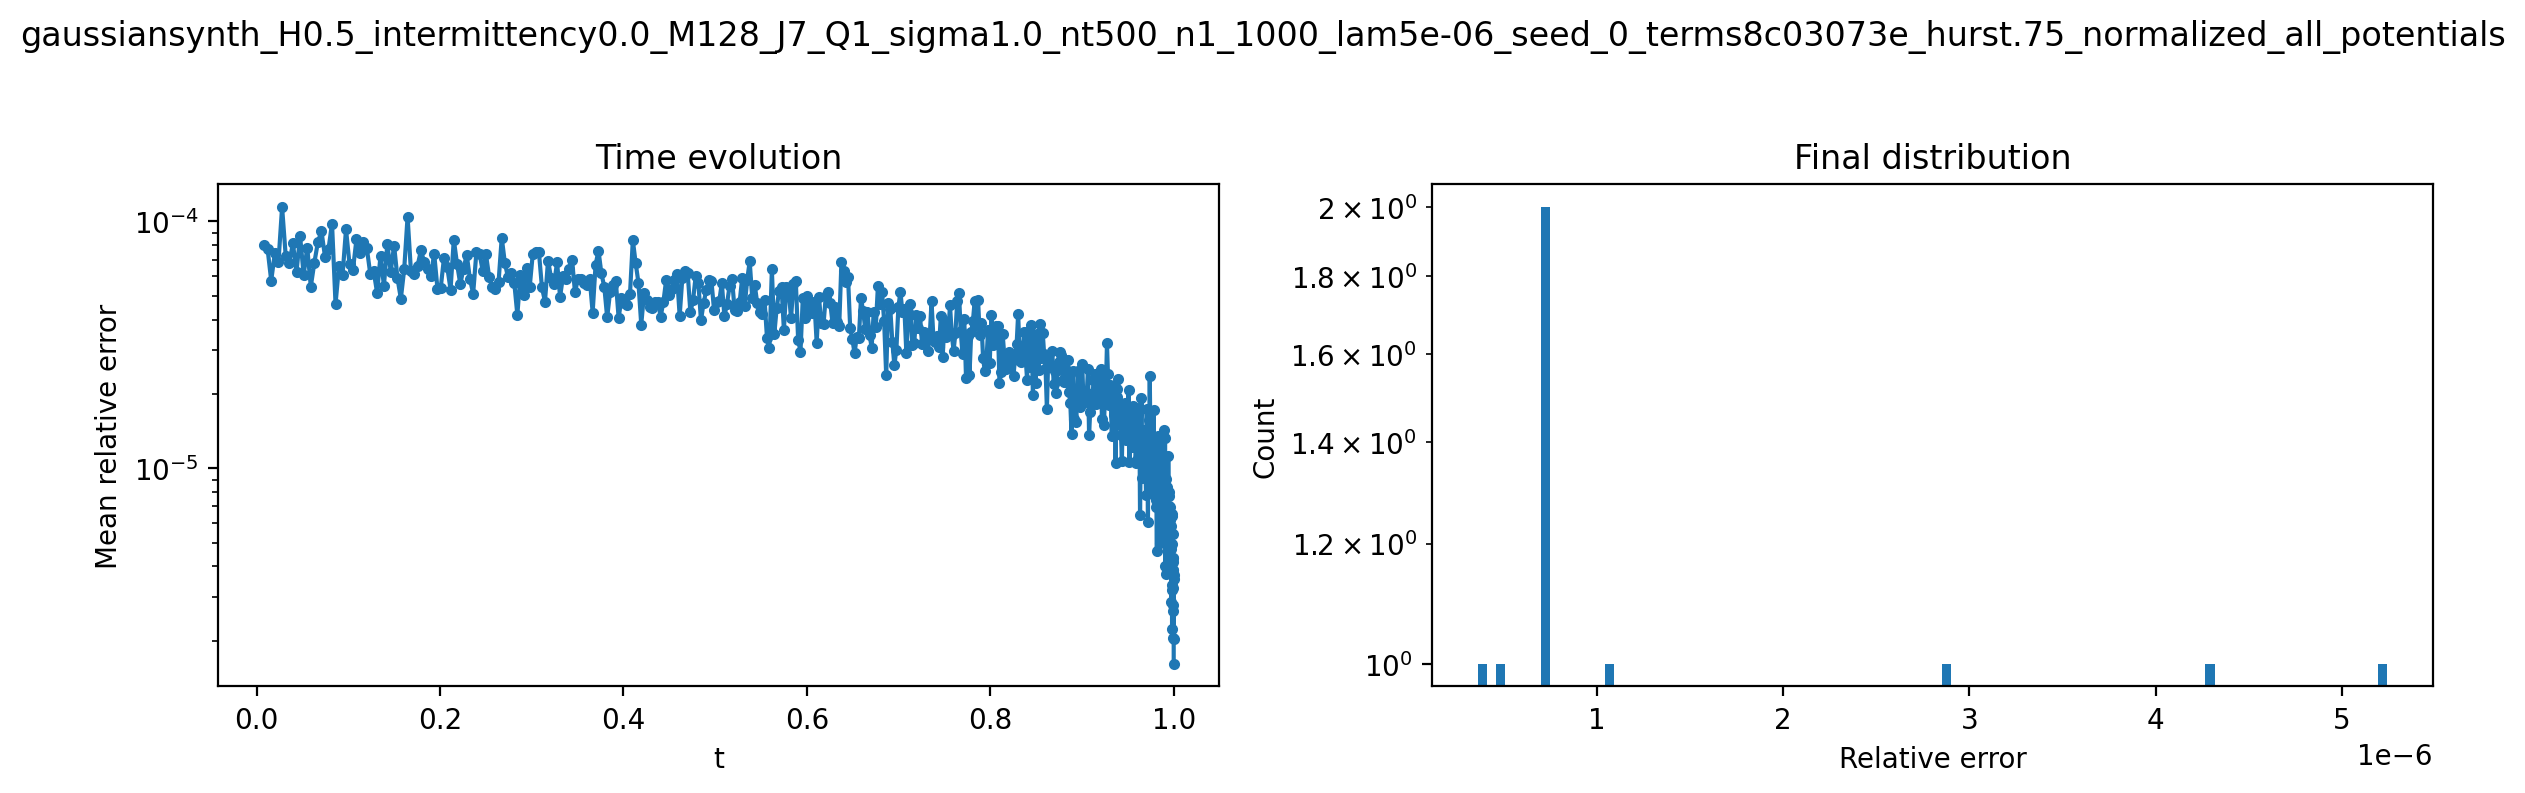

In [13]:
%matplotlib inline
if result.get('barphi_e') is not None and result.get('barphi_p') is not None:
    plot_moment_matching(result['barphi_e'], result['barphi_p'], result['t'], args.moment_threshold,
                          save={"filename": fig_dir / "moment_matching.png", "title": config})
    display(Image(filename=str(fig_dir / "moment_matching.png")))
else:
    print('No aux moments available (loaded a run without the saved aux file?); skipping.')


### True vs synthesized trajectories

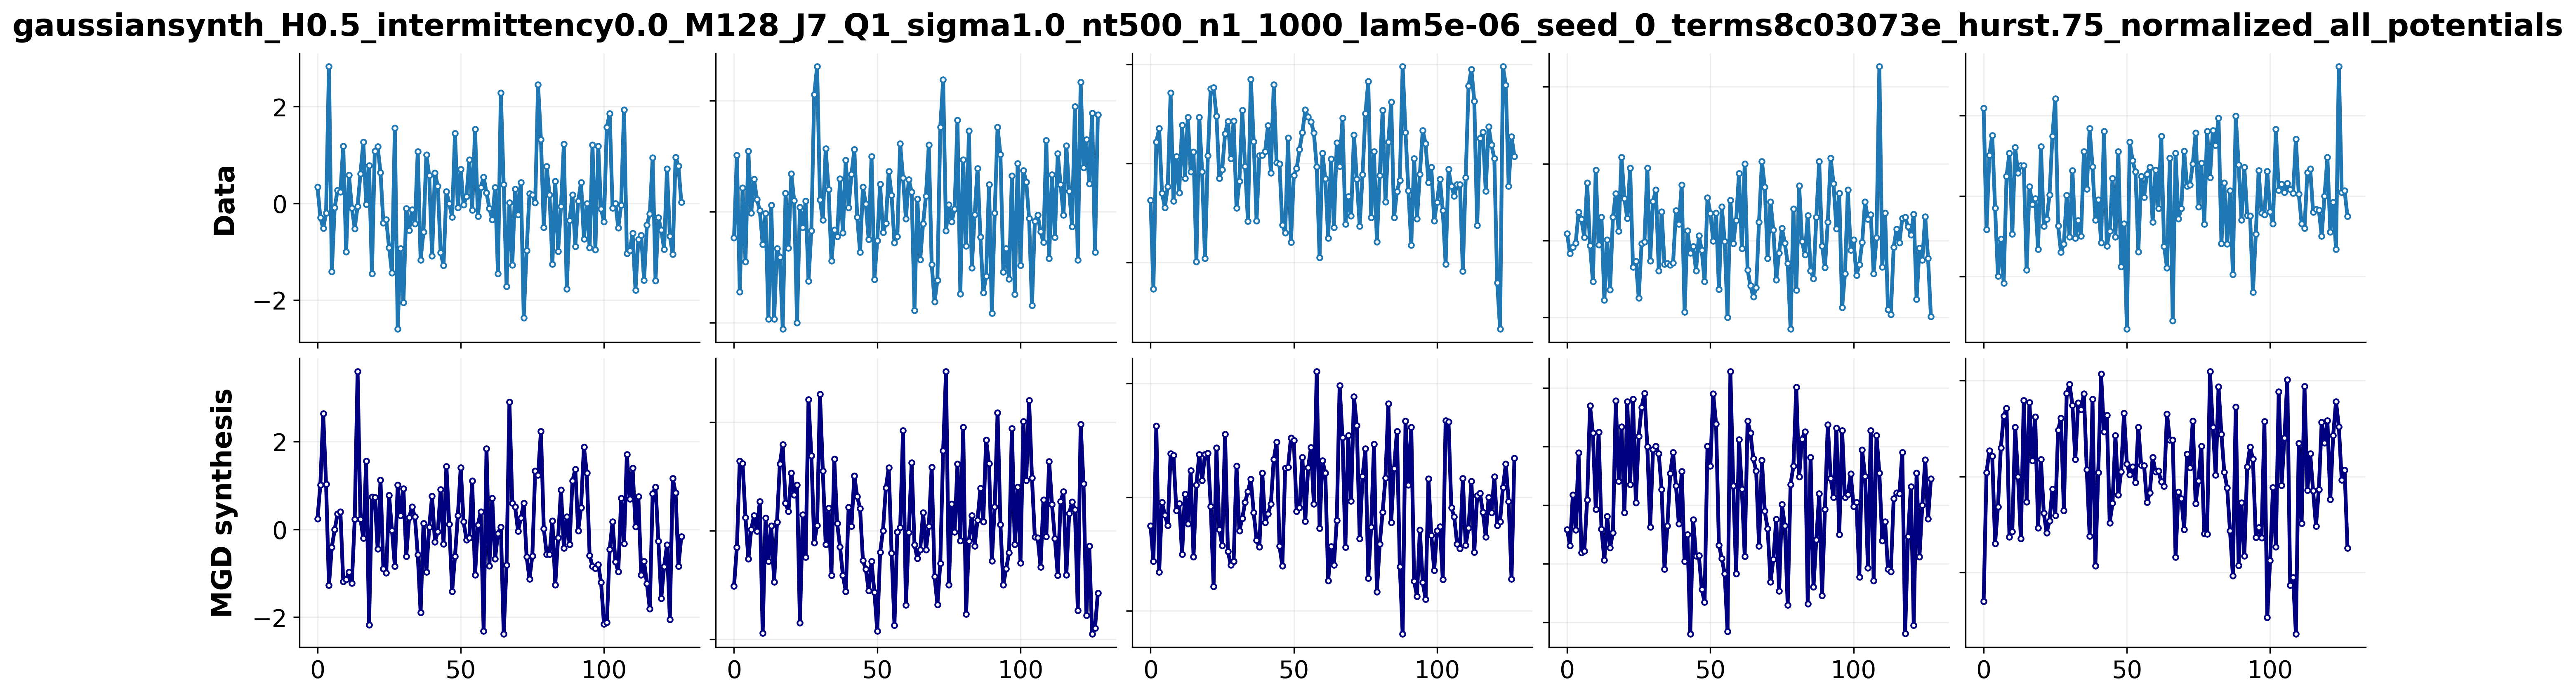

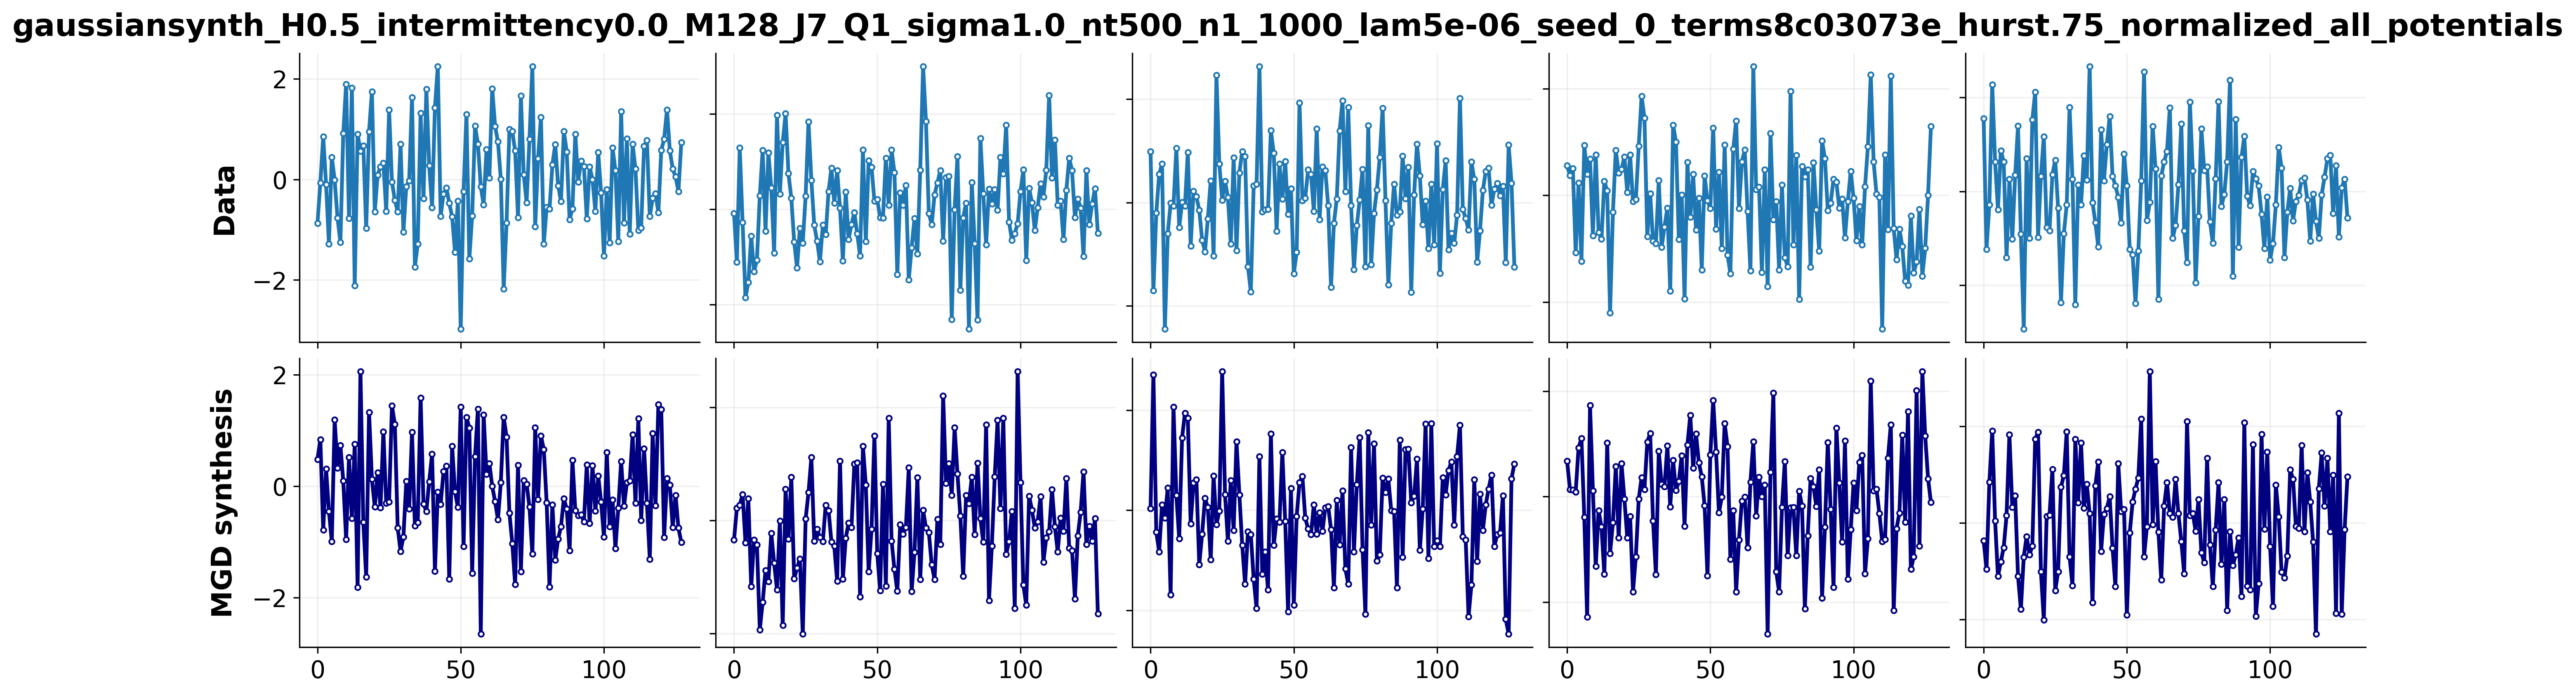

In [14]:
%matplotlib inline
n_groups = max(1, min(args.n_traj_groups, x1.shape[0] // 5))
for i in range(n_groups):
    Compare_time_series_row(x1[i*5:i*5+5], result['xt'][i*5:i*5+5], 5,
                             save={"filename": fig_dir / "compare_time_series.png", "title": config})
    display(Image(filename=str(fig_dir / "compare_time_series.png")))


### Histograms, spectrum, structure functions

(`spec_plot` displays inline but — see note above — writes no file.)


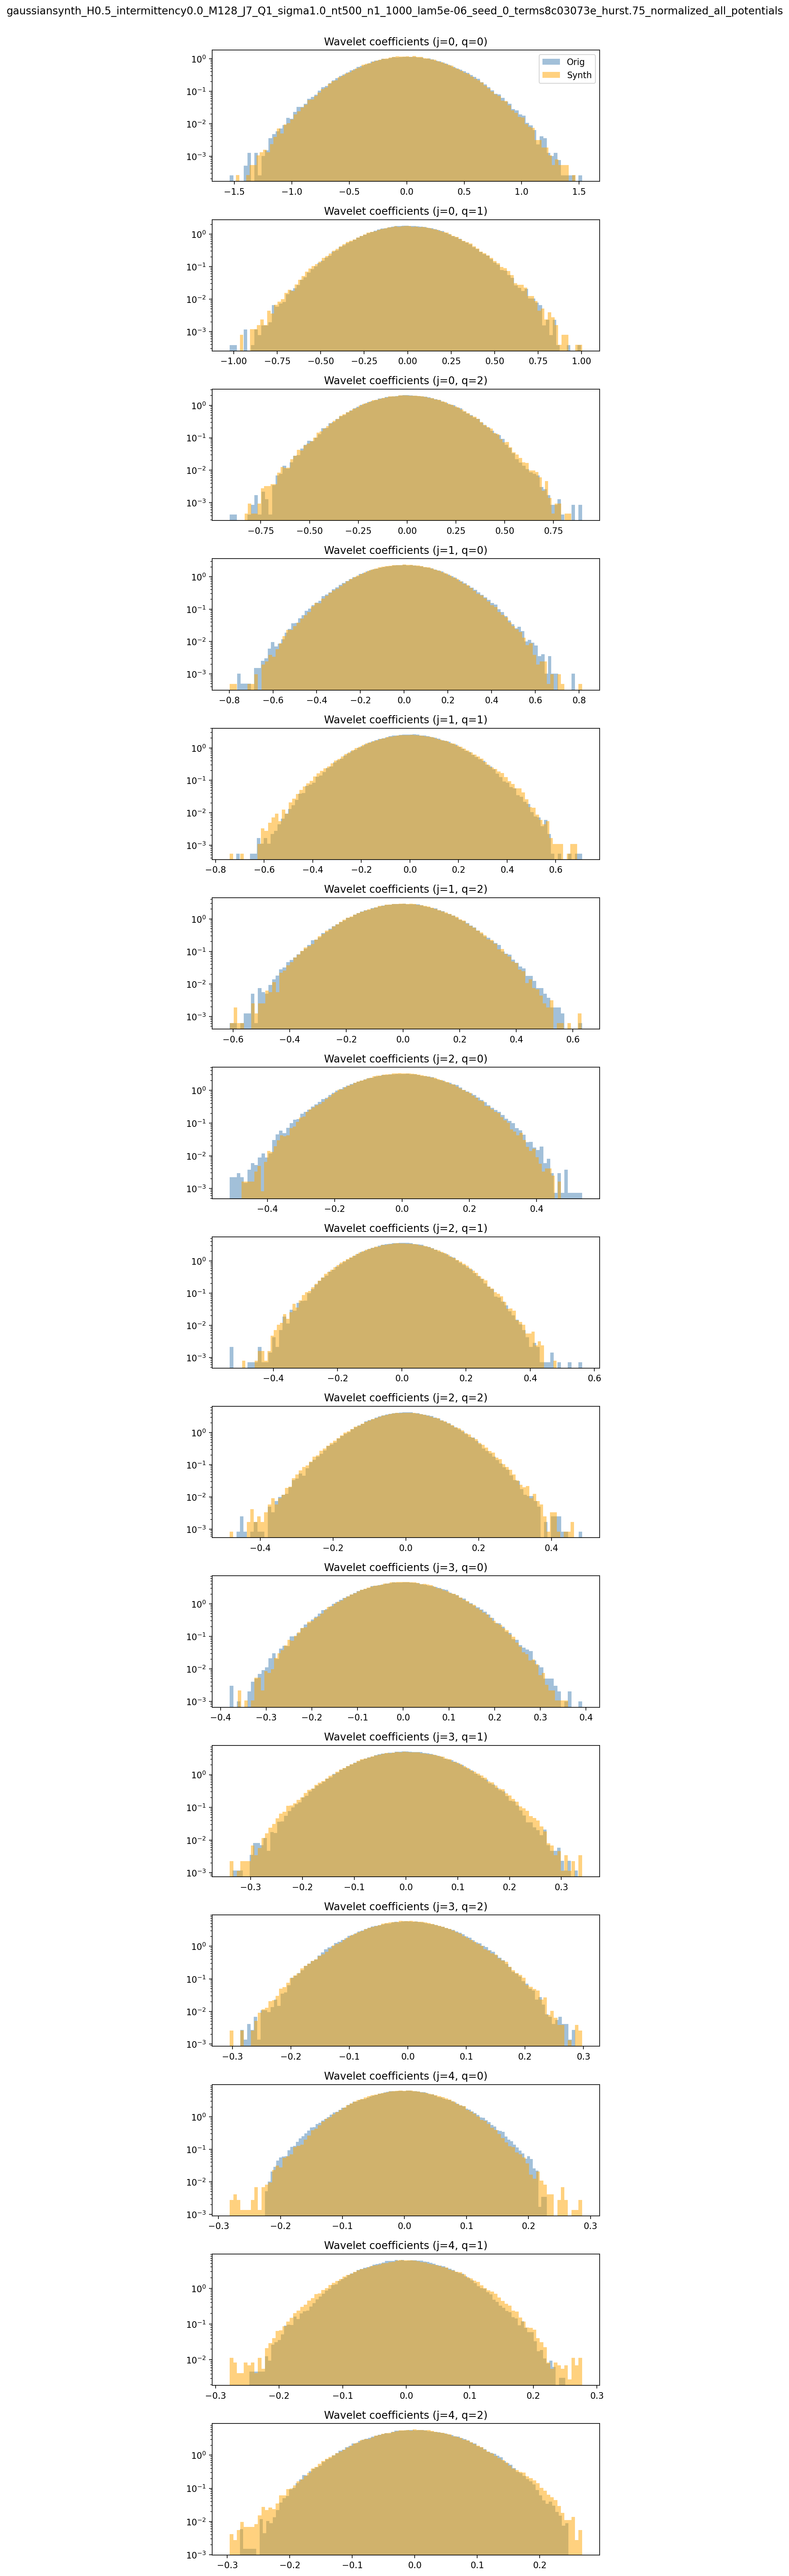

In [15]:
%matplotlib inline
hist_plot(x1, result['xt'], save={"filename": fig_dir / "histograms.png", "title": config})
display(Image(filename=str(fig_dir / "histograms.png")))


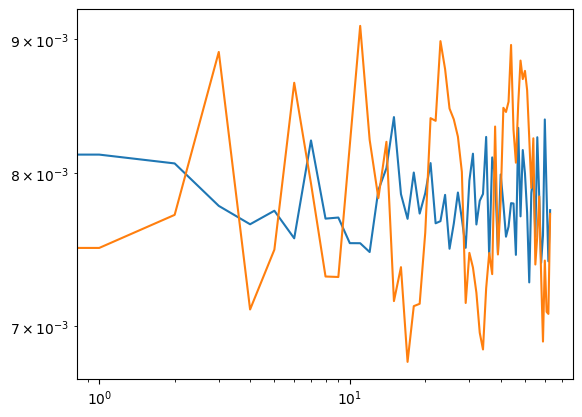

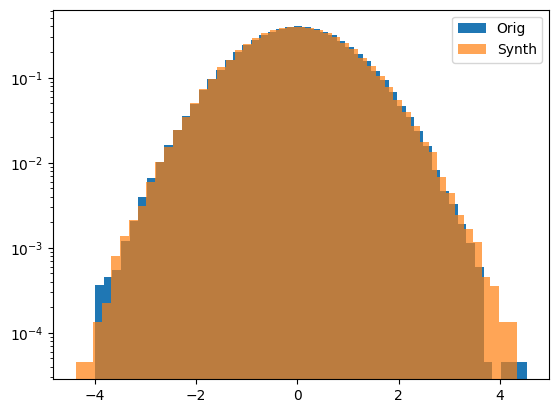

In [16]:
%matplotlib inline
spec_plot(x1, result['xt'], save={"filename": fig_dir / "spectrum.png", "title": config})


Computing structure functions for 63 lags...
Computing structure functions for 63 lags...


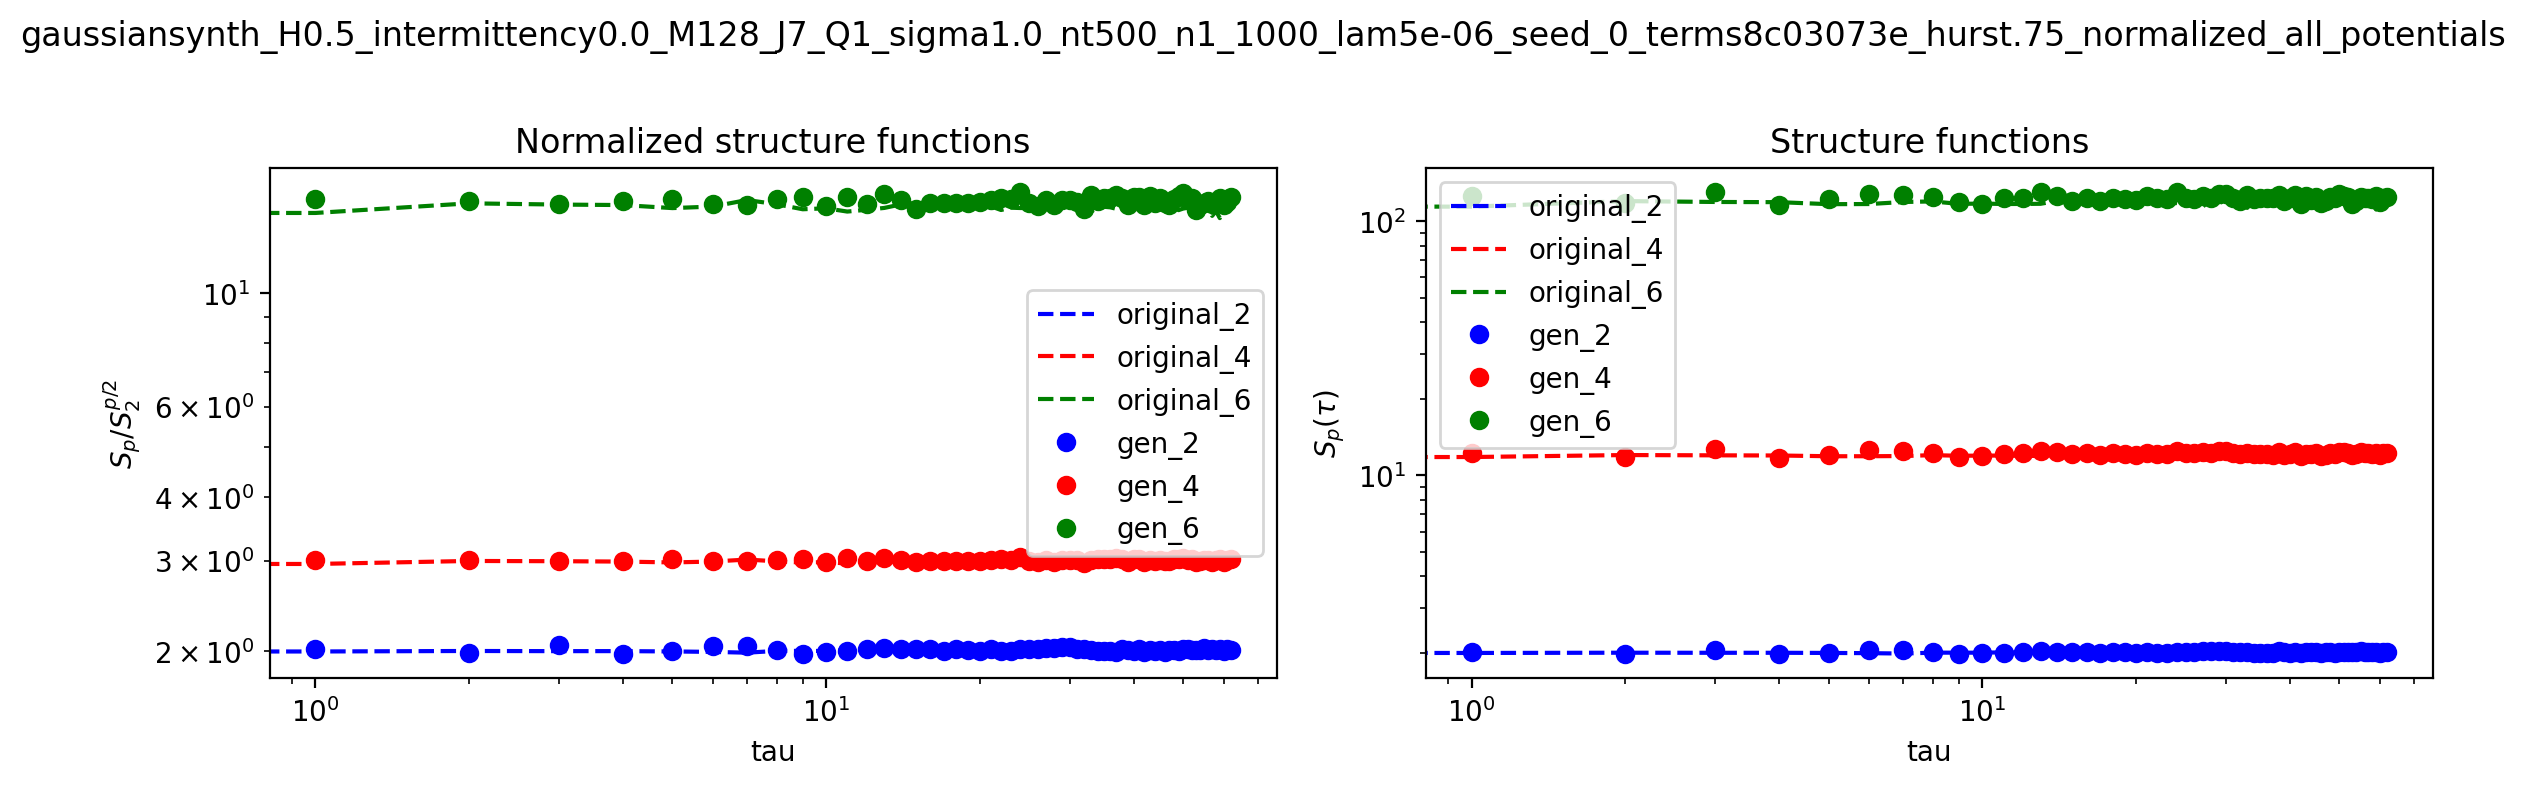

In [17]:
%matplotlib inline
structure_plot(x1, result['xt'], save={"filename": fig_dir / "structure_functions.png", "title": config})
display(Image(filename=str(fig_dir / "structure_functions.png")))


## Verify against `run_SDE.py`'s output

Sanity check that this notebook wrote exactly the files `run_SDE.py` would
for the same config (same folder, same names) — should print the same 8
filenames both scripts produce (`spectrum.png` excluded for the reason
above).


In [16]:
sorted(p.name for p in fig_dir.glob('*.png'))


['compare_time_series.png',
 'histograms.png',
 'increment_diagnostics.png',
 'moment_matching.png',
 'scaling_exponent_ratio.png',
 'structure_functions.png',
 'wavelet_histo_Q1.png',
 'wavelet_histo_Q3.png']